In [63]:
### Importing required library 
import numpy as np 
from rdkit.Chem import AllChem
import pickle
import pandas as pd
from rdkit import Chem
import xgboost
import base64
import pickle
import numpy as np
import pandas as pd
from rdkit import Chem,DataStructs
from rdkit.Chem import MolFromSmiles, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
import base64
import shap
from xgboost import XGBRegressor
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import requests
from bs4 import BeautifulSoup
import deepchem as dc
from sklearn.preprocessing import StandardScaler

In [111]:
import pandas as pd 
df_set1 = pd.read_excel('../data/JCIM_Prediction/JCIM_test.xlsx', sheet_name="SET1")
df_set2 = pd.read_excel('../data/JCIM_Prediction/JCIM_test.xlsx', sheet_name="SET2")

In [112]:
print(df_set1.shape)
print(df_set2.shape)

(100, 4)
(32, 4)


In [113]:
df_set1

,Sr No,COMPOUND_Name,SMILES,logS
0,1,Acetazolamide,CC(NC1=NN=C(S1)[S](N)(=O)=O)=O,-2.38
1,2,Acetylsalicylic_Acid,C(C)(=O)OC1=CC=CC=C1C(=O)O,-1.67
2,3,Alclofenac,C=CCOc1ccc(cc1Cl)CC(=O)O,-4.40
3,4,Ambroxol,O[C@@H]2CC[C@@H](NCc1cc(Br)cc(Br)c1N)CC2,-3.87
4,5,Aripiprazole,O=C1Nc2c(ccc(OCCCCN3CCN(c4c(Cl)c(Cl)ccc4)CC3)c...,-6.64
...,...,...,...,...
95,96,Thiacetazone,C1=C(C=CC(=C1)NC(=O)C)/C=N/NC(=S)N,-3.50
96,97,Triamcinolone,[C@]23([C@H]([C@H]1[C@]([C@](C(CO)=O)(O)[C@@H]...,-3.52
97,98,Triamterene,C3=C(C1=C(N=C2C(=N1)C(=NC(=N2)N)N)N)C=CC=C3,-4.11
98,99,Warfarin,C3=C(C(C1=C(OC2=C(C1=O)C=CC=C2)O)CC(=O)C)C=CC=C3,-4.78


In [74]:
train_set=pd.read_csv('../data/final_data/final_unique_train.csv')

In [75]:
from rdkit.Chem import MolFromSmiles as smi2mol
from rdkit.Chem import MolToSmiles as mol2smi

## Function to create canonical smiles 
def canon(smi):
    try:
        mol=smi2mol(smi, sanitize=True)
        smi_canon=mol2smi(mol, isomericSmiles=False, canonical=True)
        return(smi_canon)
    except:
        print("ERROR")
        return(smi)

In [117]:
df_set1['smiles_canon'] = [canon(smi) for smi in df_set1.SMILES]
df_set2['smiles_canon'] = [canon(smi) for smi in df_set2.SMILES]

In [77]:
train_set.shape

(17937, 8)

In [78]:
### Finding the match between train and test data 
Match_rows_set1 = pd.merge(df_set1, train_set, on=['smiles_canon'], how='inner')
#mergedStuff.head()
print(len(Match_rows_set1))

37


In [79]:
### Finding the matching smiles in the train dataset..and removing it 
cond = train_set['smiles_canon'].isin(Match_rows_set1['smiles_canon'])

#### Dropping the smiles which is same and making dataframe with uniques smiles and no smiles same in ttrain  dataset 
train_set.drop(train_set[cond].index, inplace = True)

In [80]:
train_set.shape

(17900, 8)

In [81]:
### Match with remaining train set 
Match_rows_set2 = pd.merge(df_set2, train_set, on=['smiles_canon'], how='inner')
#mergedStuff.head()
print(len(Match_rows_set2))

16


In [82]:
### Finding the matching smiles in the train dataset..and removing it 
cond = train_set['smiles_canon'].isin(Match_rows_set2['smiles_canon'])

#### Dropping the smiles which is same and making dataframe with uniques smiles and no smiles same in ttrain  dataset 
train_set.drop(train_set[cond].index, inplace = True)

In [83]:
train_set.shape

(17884, 8)

In [15]:
### Now there is no data in train set which match with df_set1 or df_set2 

In [114]:
### After removing the data match with train data 
print(df_set1.shape)
print(df_set2.shape) 

(100, 4)
(32, 4)


In [85]:
import utilities

In [86]:
### Taking out smiles from train data 
SMILES=train_set.smiles_canon

In [87]:
combined_df = utilities.create_feature_multiple(SMILES)

[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not removing hydrogen atom without neighbors
[01:02:45] WARNING: not r

In [99]:
y_train=train_set['LogS']

In [107]:
df_set1

,Sr No,COMPOUND_Name,SMILES
0,1,Acetazolamide,CC(NC1=NN=C(S1)[S](N)(=O)=O)=O
1,2,Acetylsalicylic_Acid,C(C)(=O)OC1=CC=CC=C1C(=O)O
2,3,Alclofenac,C=CCOc1ccc(cc1Cl)CC(=O)O
3,4,Ambroxol,O[C@@H]2CC[C@@H](NCc1cc(Br)cc(Br)c1N)CC2
4,5,Aripiprazole,O=C1Nc2c(ccc(OCCCCN3CCN(c4c(Cl)c(Cl)ccc4)CC3)c...
...,...,...,...
95,96,Thiacetazone,C1=C(C=CC(=C1)NC(=O)C)/C=N/NC(=S)N
96,97,Triamcinolone,[C@]23([C@H]([C@H]1[C@]([C@](C(CO)=O)(O)[C@@H]...
97,98,Triamterene,C3=C(C1=C(N=C2C(=N1)C(=NC(=N2)N)N)N)C=CC=C3
98,99,Warfarin,C3=C(C(C1=C(OC2=C(C1=O)C=CC=C2)O)CC(=O)C)C=CC=C3


In [115]:
y_set1=df_set1['logS']
y_set2=df_set2['logS']

In [118]:
### Taking out set1 and set2 smiles 
SMILES_test1=df_set1.smiles_canon
SMILES_test2=df_set2.smiles_canon

In [119]:
### calculate the descriptors for set anmd set2 
df_test1 = utilities.create_feature_multiple(SMILES_test1)
df_test2 = utilities.create_feature_multiple(SMILES_test2)

In [121]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np


In [122]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Metrics list
mae_scores = []
rmse_scores = []
r2_scores = []

test_predictions=[]

# Loop through each fold
for train_index, val_index in kf.split(combined_df):
    # Splitting train data into training and validation for the current fold
    X_train_fold, X_val_fold = combined_df.iloc[train_index], combined_df.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    

    
    # Initialize model to get trained on train dataset 
    model = xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
    model.fit(X_train_fold, y_train_fold)
    

    
    
    
    # Test predictions for this fold
    y_test_pred = model.predict(df_test1)
    test_predictions.append(y_test_pred)
    mae = mean_absolute_error(y_set1, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_set1, y_test_pred))
    r2 = r2_score(y_set1, y_test_pred)
    
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)


# Calculate mean and standard deviation of metrics across all folds
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)



# Output results
print("Mean and Standard Deviation of Metrics Across 5 Folds:")
print(f"MAE: Mean = {mean_mae:.4f}, Std = {std_mae:.4f}")
print(f"RMSE: Mean = {mean_rmse:.4f}, Std = {std_rmse:.4f}")
print(f"R²: Mean = {mean_r2:.4f}, Std = {std_r2:.4f}")



Mean and Standard Deviation of Metrics Across 5 Folds:
MAE: Mean = 0.7977, Std = 0.0145
RMSE: Mean = 1.0317, Std = 0.0120
R²: Mean = 0.3357, Std = 0.0153


In [123]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Metrics list
mae_scores = []
rmse_scores = []
r2_scores = []

test_predictions=[]

# Loop through each fold
for train_index, val_index in kf.split(combined_df):
    # Splitting train data into training and validation for the current fold
    X_train_fold, X_val_fold = combined_df.iloc[train_index], combined_df.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    

    
    # Initialize model (you can replace this with any model)
    model = xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
    model.fit(X_train_fold, y_train_fold)
    

    
    
    
    # Test predictions for this fold
    y_test_pred = model.predict(df_test2)
    test_predictions.append(y_test_pred)
    mae = mean_absolute_error(y_set2, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_set2, y_test_pred))
    r2 = r2_score(y_set2, y_test_pred)
    
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)


# Calculate mean and standard deviation of metrics across all folds
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)



# Output results
print("Mean and Standard Deviation of Metrics Across 5 Folds:")
print(f"MAE: Mean = {mean_mae:.4f}, Std = {std_mae:.4f}")
print(f"RMSE: Mean = {mean_rmse:.4f}, Std = {std_rmse:.4f}")
print(f"R²: Mean = {mean_r2:.4f}, Std = {std_r2:.4f}")



Mean and Standard Deviation of Metrics Across 5 Folds:
MAE: Mean = 0.9000, Std = 0.0451
RMSE: Mean = 1.1580, Std = 0.0697
R²: Mean = 0.7066, Std = 0.0351


In [124]:
### Predicting on test data set1 
y_test_pred_set3 = model.predict(df_test1)
### Predicting on test data set1 
y_test_pred_set4 = model.predict(df_test2)

In [125]:
### Calculation of RMSE for set 1
rmse_set1 = np.sqrt(mean_squared_error(y_set1, y_test_pred_set3))
print(rmse_set1)

1.037014247979719


In [126]:
### Calculation of RMSE for set 2
rmse_set2 = np.sqrt(mean_squared_error(y_set2, y_test_pred_set4))
print(rmse_set2)

1.0536280507240483


In [50]:
### Adding the predicted values in dataframe set1 and set 2 
df_set1['Predicted_LogS']=y_test_pred_set3
df_set2['Predicted_LogS']=y_test_pred_set4

In [51]:
### Adding the Molecular weight in dataframe set1 and set 2 
def calc_mol_weight(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Descriptors.MolWt(mol)
    return None

# Apply the function to the SMILES column
df_set1['MW'] = df_set1['SMILES'].apply(calc_mol_weight)
df_set2['MW'] = df_set2['SMILES'].apply(calc_mol_weight)

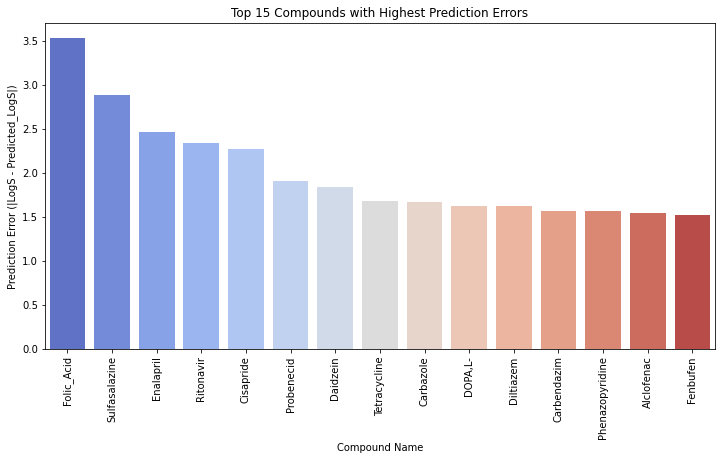

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set1["Error"] = abs(df_set1["LogS"] - df_set1["Predicted_LogS"])

# Sort by error magnitude (descending)
df_sorted = df_set1.sort_values(by="Error", ascending=False)

# Plot the top 15 compounds with highest errors
plt.figure(figsize=(12,6))
sns.barplot(x=df_sorted["COMPOUND_Name"][:15], y=df_sorted["Error"][:15], palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Compound Name")
plt.ylabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.title("Top 15 Compounds with Highest Prediction Errors")
plt.show()


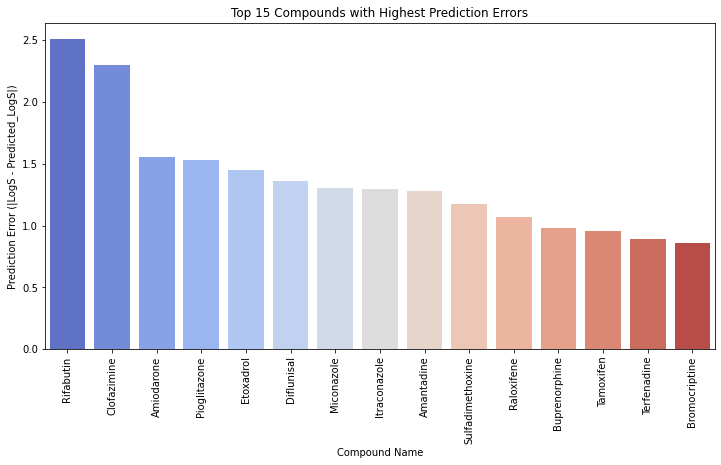

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set2["Error"] = abs(df_set2["LogS"] - df_set2["Predicted_LogS"])

# Sort by error magnitude (descending)
df_sorted = df_set2.sort_values(by="Error", ascending=False)

# Plot the top 15 compounds with highest errors
plt.figure(figsize=(12,6))
sns.barplot(x=df_sorted["COMPOUND"][:15], y=df_sorted["Error"][:15], palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Compound Name")
plt.ylabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.title("Top 15 Compounds with Highest Prediction Errors")
plt.show()

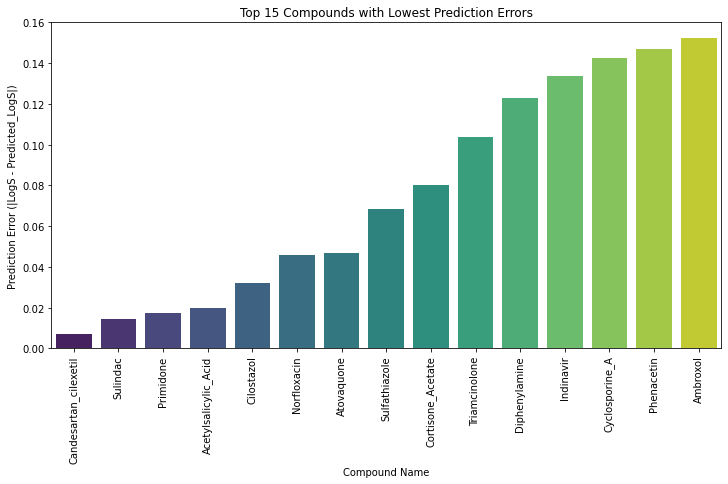

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set1["Error"] = abs(df_set1["LogS"] - df_set1["Predicted_LogS"])

# Sort by lowest error magnitude
df_sorted_lowest = df_set1.sort_values(by="Error", ascending=True)

# Plot the top 15 compounds with the lowest errors
plt.figure(figsize=(12,6))
sns.barplot(x=df_sorted_lowest["COMPOUND_Name"][:15], y=df_sorted_lowest["Error"][:15], palette="viridis")
plt.xticks(rotation=90)
plt.xlabel("Compound Name")
plt.ylabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.title("Top 15 Compounds with Lowest Prediction Errors")
plt.show()


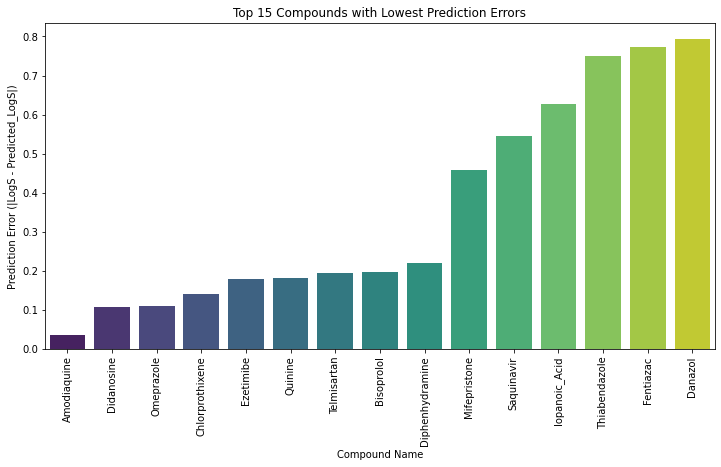

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set2["Error"] = abs(df_set2["LogS"] - df_set2["Predicted_LogS"])

# Sort by lowest error magnitude
df_sorted_lowest = df_set2.sort_values(by="Error", ascending=True)

# Plot the top 15 compounds with the lowest errors
plt.figure(figsize=(12,6))
sns.barplot(x=df_sorted_lowest["COMPOUND"][:15], y=df_sorted_lowest["Error"][:15], palette="viridis")
plt.xticks(rotation=90)
plt.xlabel("Compound Name")
plt.ylabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.title("Top 15 Compounds with Lowest Prediction Errors")
plt.show()

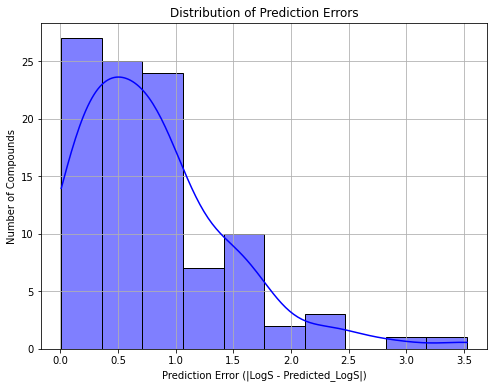

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set1["Error"] = abs(df_set1["LogS"] - df_set1["Predicted_LogS"])

# Plot histogram of error distribution
plt.figure(figsize=(8,6))
sns.histplot(df_set1["Error"], bins=10, kde=True, color="blue")  # 10 bins for better grouping

plt.xlabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
plt.show()


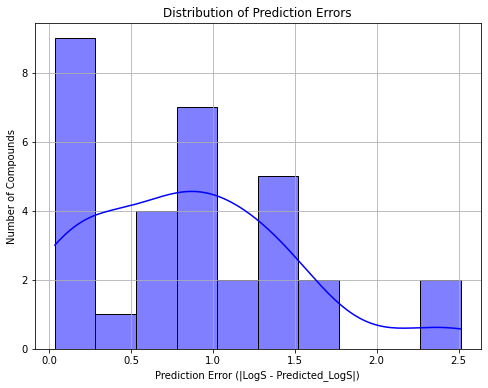

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set2["Error"] = abs(df_set2["LogS"] - df_set2["Predicted_LogS"])

# Plot histogram of error distribution
plt.figure(figsize=(8,6))
sns.histplot(df_set2["Error"], bins=10, kde=True, color="blue")  # 10 bins for better grouping

plt.xlabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
plt.show()

In [58]:
df_set1['Sol_g_l']=(10**df_set1.Predicted_LogS)*df_set1.MW
df_set2['Sol_g_l']=(10**df_set2.Predicted_LogS)*df_set2.MW

In [59]:
### saving the predicted csv file to the disk 

df_set1.to_csv("JCIM_set1_prediction.csv", index=False)  ### 100 compounds 
df_set2.to_csv("JCIM_set2_prediction.csv", index=False)  ### 32 compounds 

In [60]:
df_set1["Error"] = abs(df_set1["LogS"] - df_set1["Predicted_LogS"])

# Count compounds with error within ±0.5
count_within_threshold = df_set1[df_set1["Error"] <= 0.5].shape[0]
total_compounds = df_set1.shape[0]
percentage_within_threshold = (count_within_threshold / total_compounds) * 100

print(f"Percentage of compounds with error within ±0.5: {percentage_within_threshold:.2f}%")



print(f"Number of compounds with error within ±0.5: {count_within_threshold}")

Percentage of compounds with error within ±0.5: 38.00%
Number of compounds with error within ±0.5: 38


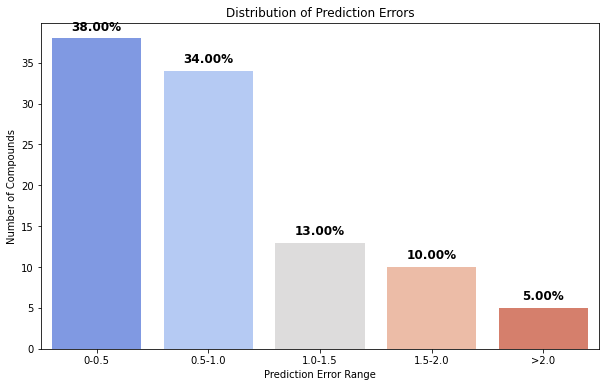

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set1["Error"] = abs(df_set1["LogS"] - df_set1["Predicted_LogS"])

# Define bins and labels
bins = [0, 0.5, 1.0, 1.5, 2.0, float("inf")]
labels = ["0-0.5", "0.5-1.0", "1.0-1.5", "1.5-2.0", ">2.0"]

# Create a new column for error bins
df_set1["Error Bin"] = pd.cut(df_set1["Error"], bins=bins, labels=labels, right=False)

# Count occurrences in each bin
bin_counts = df_set1["Error Bin"].value_counts().reindex(labels, fill_value=0)

# Calculate percentages
total_compounds = df_set1.shape[0]
bin_percentages = (bin_counts / total_compounds) * 100

# Plot the bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=bin_counts.index, y=bin_counts.values, palette="coolwarm")

# Add percentages on top of bars
for i, count in enumerate(bin_counts.values):
    plt.text(i, count + 1, f"{bin_percentages[i]:.2f}%", ha='center', fontsize=12, fontweight='bold')

plt.xlabel("Prediction Error Range")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Prediction Errors")
plt.show()


In [62]:
df_set2["Error"] = abs(df_set2["LogS"] - df_set2["Predicted_LogS"])

# Count compounds with error within ±0.5
count_within_threshold = df_set2[df_set2["Error"] <= 0.5].shape[0]


# Calculate percentage
total_compounds = df_set2.shape[0]
percentage_within_threshold = (count_within_threshold / total_compounds) * 100

print(f"Percentage of compounds with error within ±0.5: {percentage_within_threshold:.2f}%")


print(f"Number of compounds with error within ±0.5: {count_within_threshold}")

Percentage of compounds with error within ±0.5: 31.25%
Number of compounds with error within ±0.5: 10


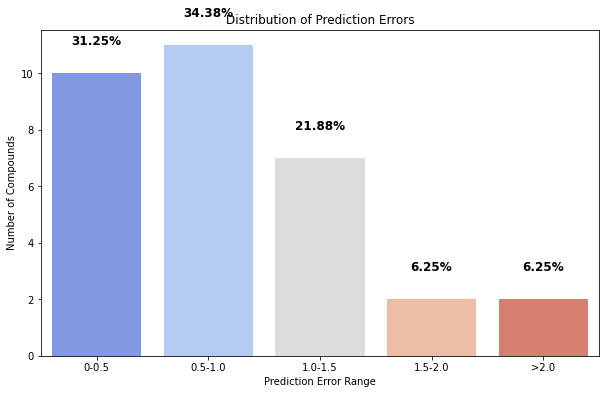

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set2["Error"] = abs(df_set2["LogS"] - df_set2["Predicted_LogS"])

# Define bins and labels
bins = [0, 0.5, 1.0, 1.5, 2.0, float("inf")]
labels = ["0-0.5", "0.5-1.0", "1.0-1.5", "1.5-2.0", ">2.0"]

# Create a new column for error bins
df_set2["Error Bin"] = pd.cut(df_set2["Error"], bins=bins, labels=labels, right=False)

# Count occurrences in each bin
bin_counts = df_set2["Error Bin"].value_counts().reindex(labels, fill_value=0)

# Calculate percentages
total_compounds = df_set2.shape[0]
bin_percentages = (bin_counts / total_compounds) * 100

# Plot the bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=bin_counts.index, y=bin_counts.values, palette="coolwarm")

# Add percentages on top of bars
for i, count in enumerate(bin_counts.values):
    plt.text(i, count + 1, f"{bin_percentages[i]:.2f}%", ha='center', fontsize=12, fontweight='bold')

plt.xlabel("Prediction Error Range")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Prediction Errors")
plt.show()


In [175]:
### Taking out the others users prediction and actual data for set1 
import pandas as pd 
df_set1 = pd.read_excel('../data/JCIM_Prediction/JCIM_competition_test.xlsx', sheet_name="SET1")

In [176]:
### Taking out the others users prediction and actual data for set2 
df_set2 = pd.read_excel('../data/JCIM_Prediction/JCIM_competition_test.xlsx', sheet_name="SET2")

In [155]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Extract actual values (first column)
actual_values = df_set1.iloc[:, 0]

# Initialize a dictionary to store RMSE results
rmse_results = {}

# Loop through the predicted columns (users' predictions)
for col in df_set1.columns[1:]:  # Skipping the first column (actual values)
    predicted_values = df_set1[col]
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
    rmse_results[col] = rmse  # Store RMSE for each user

# Convert results to a DataFrame for better visualization
rmse_df_set1 = pd.DataFrame(list(rmse_results.items()), columns=["User", "RMSE1"])

# Calculate the average RMSE for set1 
num_users = len(rmse_results)  # Count actual number of predicted columns
average_rmse_set1 = sum(rmse_results.values()) / num_users if num_users > 0 else 0
print(f"Average RMSE SET1: {average_rmse_set1}")



Average RMSE SET1: 1.1369027497517306


In [156]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Load your dataframe (Assuming it's already loaded as df)
# df = pd.read_csv("your_file.csv")

# Extract actual values (first column)
actual_values = df_set2.iloc[:, 0]

# Initialize a dictionary to store RMSE results
rmse_results = {}

# Loop through the predicted columns (users' predictions)
for col in df_set2.columns[1:]:  # Skipping the first column (actual values)
    predicted_values = df_set2[col]
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
    rmse_results[col] = rmse  # Store RMSE for each user

# Calculate the average RMSE for set2 
num_users = len(rmse_results)  # Count actual number of predicted columns
average_rmse_set2 = sum(rmse_results.values()) / num_users if num_users > 0 else 0
print(f"Average RMSE SET2: {average_rmse_set2}")

# Convert results to a DataFrame for better visualization
rmse_df_set2 = pd.DataFrame(list(rmse_results.items()), columns=["User", "RMSE2"])



Average RMSE SET2: 1.6322268506155388


In [157]:
### Adding our RSME to others user  RSME to compare our result with others  

new_entry_set1 = {'User': 'Ali', 'RMSE1': '1.0317'}

# Add the new entry using loc (at the end of the DataFrame)
rmse_df_set1.loc[len(rmse_df_set1)] = new_entry_set1
new_entry_set2 = {'User': 'Ali', 'RMSE2': '1.0536'}

# Add the new entry using loc (at the end of the DataFrame)
rmse_df_set2.loc[len(rmse_df_set2)] = new_entry_set2


In [159]:
### combining the dataframe for set and set2 RMSE

merged_df = pd.merge(rmse_df_set1, rmse_df_set2, on='User')

In [160]:
merged_df

,User,RMSE1,RMSE2
0,ASTU,1.022883,1.246186
1,RFSPA_A,0.99669,1.905069
2,RFSPA_B,0.99669,2.033899
3,JMSA_A,0.976881,1.489623
4,JMSA_B,0.946187,1.51681
5,JMSA_C,0.989274,1.494617
6,YUMPU_A,0.763342,1.079704
7,YUMPU_B,1.406618,2.16771
8,HPSU_A,2.372672,2.16771
9,HPSU_B,2.111203,2.248437


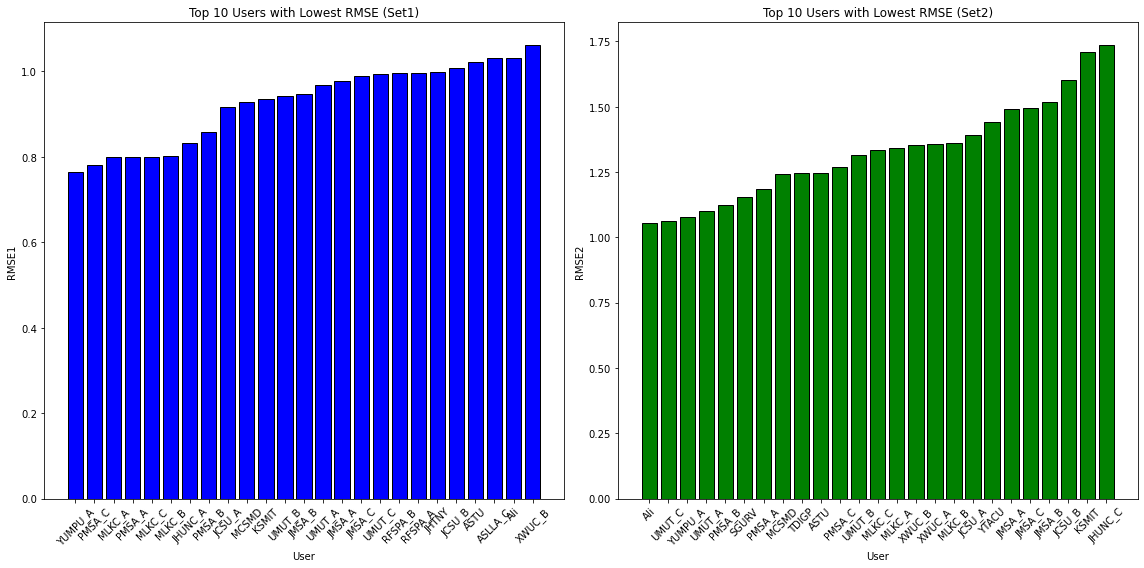

In [180]:
import pandas as pd
import matplotlib.pyplot as plt

merged_df["RMSE1"] = pd.to_numeric(merged_df["RMSE1"], errors="coerce")
merged_df["RMSE2"] = pd.to_numeric(merged_df["RMSE2"], errors="coerce")


# Sort by rmse_set1 and rmse_set2 to get top 25 lowest RMSE values
df_sorted_set1 = merged_df.sort_values(by='RMSE1').head(25)
df_sorted_set2 = merged_df.sort_values(by='RMSE2').head(25)

# Plotting the bar chart for RMSE Set1 and RMSE Set2
plt.figure(figsize=(16, 8))

# Bar chart for RMSE Set1
plt.subplot(1, 2, 1)
plt.bar(df_sorted_set1['User'], df_sorted_set1['RMSE1'], color='blue', edgecolor='black')
plt.title('Top 10 Users with Lowest RMSE (Set1)')
plt.xlabel('User')
plt.ylabel('RMSE1')
plt.xticks(rotation=45)

# Bar chart for RMSE Set2
plt.subplot(1, 2, 2)
plt.bar(df_sorted_set2['User'], df_sorted_set2['RMSE2'], color='green', edgecolor='black')
plt.title('Top 10 Users with Lowest RMSE (Set2)')
plt.xlabel('User')
plt.ylabel('RMSE2')
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


In [46]:
### End here ....